In [1]:
import pandas as pd


In [127]:
movies = pd.read_csv(r"C:\Users\sophi\Documents\csv_folder\imdb_movies.csv")

In [5]:
movies.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [13]:
movies[movies.duplicated()]

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj


In [12]:
movies.drop_duplicates(inplace = True)

In [16]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10842 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10842 non-null  int64  
 1   imdb_id               10834 non-null  object 
 2   popularity            10842 non-null  float64
 3   budget                10842 non-null  int64  
 4   revenue               10842 non-null  int64  
 5   original_title        10842 non-null  object 
 6   cast                  10767 non-null  object 
 7   homepage              2931 non-null   object 
 8   director              10800 non-null  object 
 9   tagline               8036 non-null   object 
 10  keywords              9367 non-null   object 
 11  overview              10839 non-null  object 
 12  runtime               10842 non-null  int64  
 13  genres                10842 non-null  object 
 14  production_companies  9826 non-null   object 
 15  release_date          10

 ## There are missing rows of genres which i do not need, as it will disrupt my results.
# So i am droping the columns where the genres is missing.

In [17]:
movies.dropna(subset = ['genres'], inplace = True)

In [18]:
# lets add profit column in our table

In [19]:
movies['profit'] = movies['revenue'] - movies['budget']

In [194]:
movies_genre = movies[['popularity', 'budget', 'revenue', 'original_title','runtime', 'genres', 'release_year', 'vote_count', 'vote_average', 'profit']]

In [195]:
#now we have a clean dataset with all the column required to analyse 
#however the most important column 'genres' is not useabelabs

In [196]:
# which why it needs reshaping

In [197]:
from pandas import Series , DataFrame

In [198]:
split = movies['genres'].str.split('|').apply(Series, 1).stack()
split.index = split.index.droplevel(-1)
split.name = 'genre_split'
del movies_genre['genres']
movies_genre = movies_genre.join(split)

C:\Users\sophi\AppData\Local\Temp\ipykernel_16876\2327067735.py:1: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  split = movies['genres'].str.split('|').apply(Series, 1).stack()


In [199]:
movies_genre.head()

,popularity,budget,revenue,original_title,runtime,release_year,vote_count,vote_average,profit,genre_split
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Action
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Adventure
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Science Fiction
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Thriller
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,2015,6185,7.100000,228436354,Action


In [159]:
#now we have a clean table with splited genre

In [160]:
# so lets move towards the questions needed to be replied

In [161]:
#1 Which genre are the most common (number of movies)?

In [162]:
genre_count = pd.DataFrame(movies_genre.groupby('genre_split').original_title.nunique()).sort_values('original_title', ascending = True)

<Axes: title={'center': 'Movie Genre'}, ylabel='genre_split'>

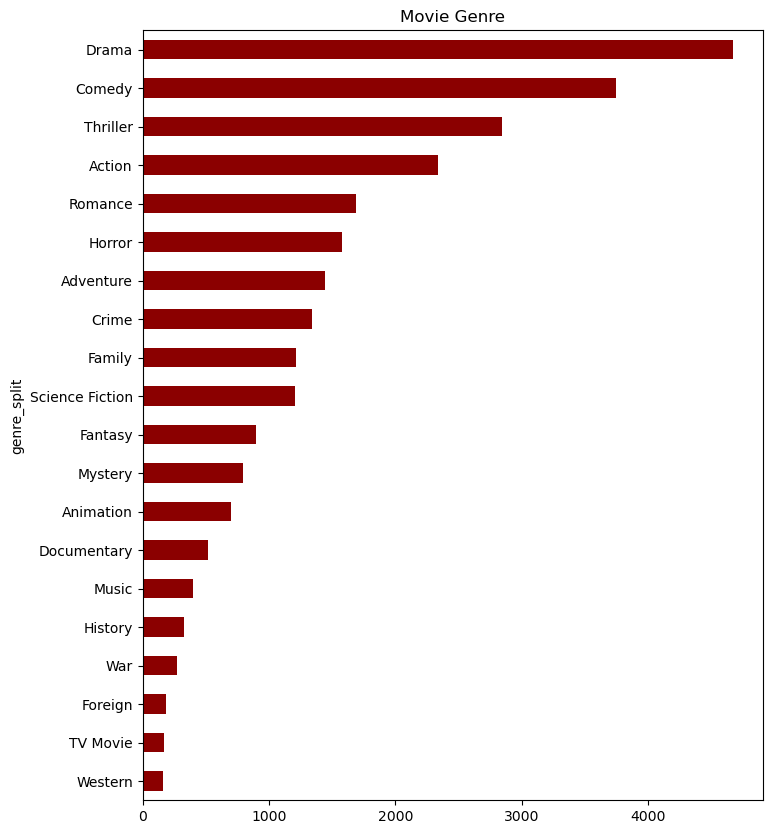

In [163]:
genre_count['original_title'].plot.barh(title = 'Movie Genre', color = 'Darkred', figsize = (8,10))

In [164]:
##2 Which genre has highest avg budgest and reveneu?

In [165]:
genre_avg = movies_genre.groupby('genre_split').mean(numeric_only = True)
pd.options.display.float_format = '{:2f}'.format
genre_avg

,popularity,budget,revenue,runtime,release_year,vote_count,vote_average,profit
genre_split,,,,,,,,
Action,0.926274,27727820.331376,72794732.002517,104.917785,2000.056208,392.993708,5.787752,45066911.671141
Adventure,1.154259,37543694.530931,113137861.069341,106.173351,1999.388851,513.125085,5.940585,75594166.538409
Animation,0.852182,23159781.606581,75256062.223176,68.181688,2003.995708,303.000000,6.403147,52096280.616595
Comedy,0.592607,13297915.618244,37526242.072238,96.745057,2000.816240,176.436330,5.905167,24228326.453994
Crime,0.744930,17663801.124815,42368661.645495,106.917282,1999.491137,278.805022,6.124889,24704860.520679
Documentary,0.181432,577149.148077,2041106.994231,102.651923,2008.313462,35.105769,6.908462,1463957.846154
Drama,0.591495,11880717.773529,29232255.725840,110.478151,2000.929202,182.544538,6.165546,17351537.952311
Family,0.786668,23359337.420796,72433176.373680,89.603574,2000.774167,272.320877,5.997563,49073838.952884
Fantasy,0.992840,32612585.348253,96313657.081878,100.736900,2000.292576,420.741266,5.863537,63701071.733624


In [166]:
genre_avg.sort_values('budget', ascending = True, inplace = True)

<Axes: title={'center': 'Budget and Revenue per Genre'}, ylabel='genre_split'>

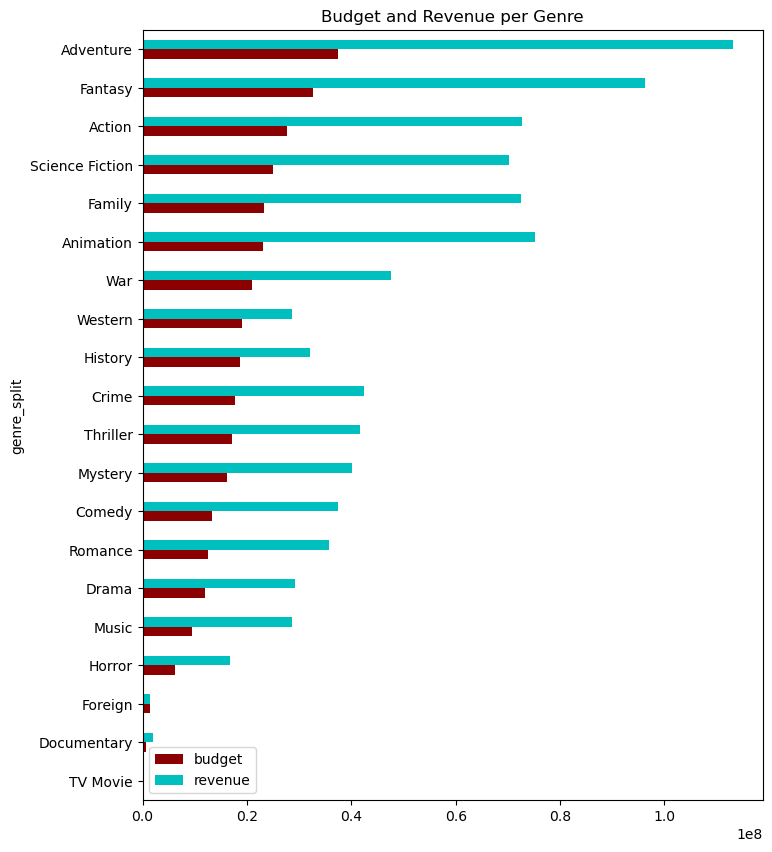

In [167]:
genre_avg[['budget', 'revenue']].plot.barh(title = 'Budget and Revenue per Genre', color =('Darkred', 'c'),figsize = (8,10))

In [168]:
# which genre has highest avg profit?

In [169]:
genre_avg.sort_values('profit', ascending = True, inplace = True)

<Axes: title={'center': 'Profit per Genre'}, ylabel='genre_split'>

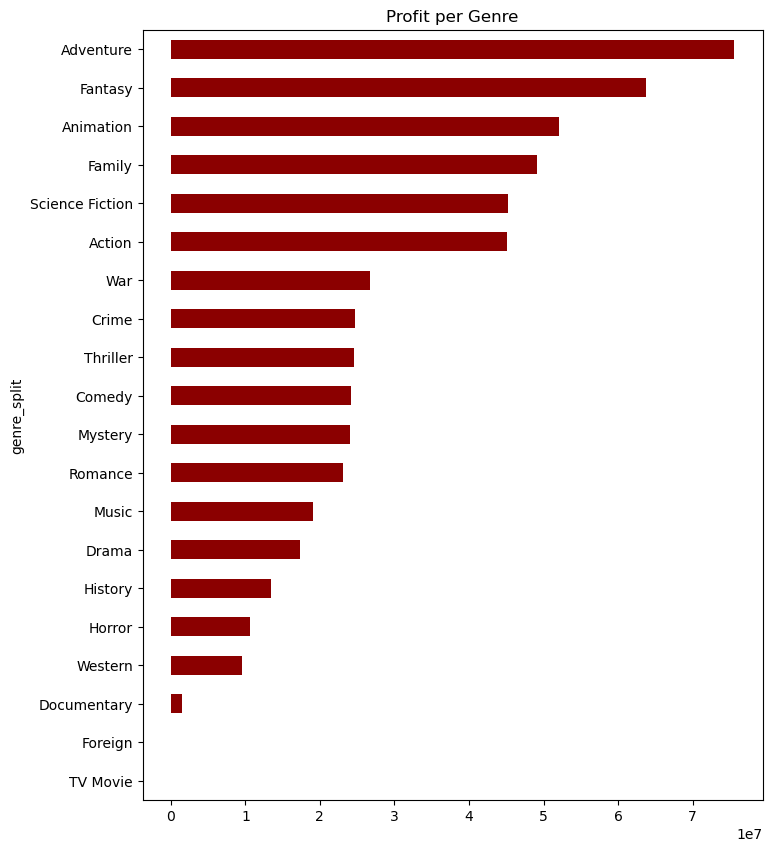

In [170]:
genre_avg['profit'].plot.barh(title = 'Profit per Genre', color = 'Darkred', figsize = (8,10))

In [171]:
# Which genre has highest popularity?

In [172]:
genre_avg.sort_values('popularity', ascending = True, inplace = True)

<Axes: title={'center': 'Popularity per Genre'}, ylabel='genre_split'>

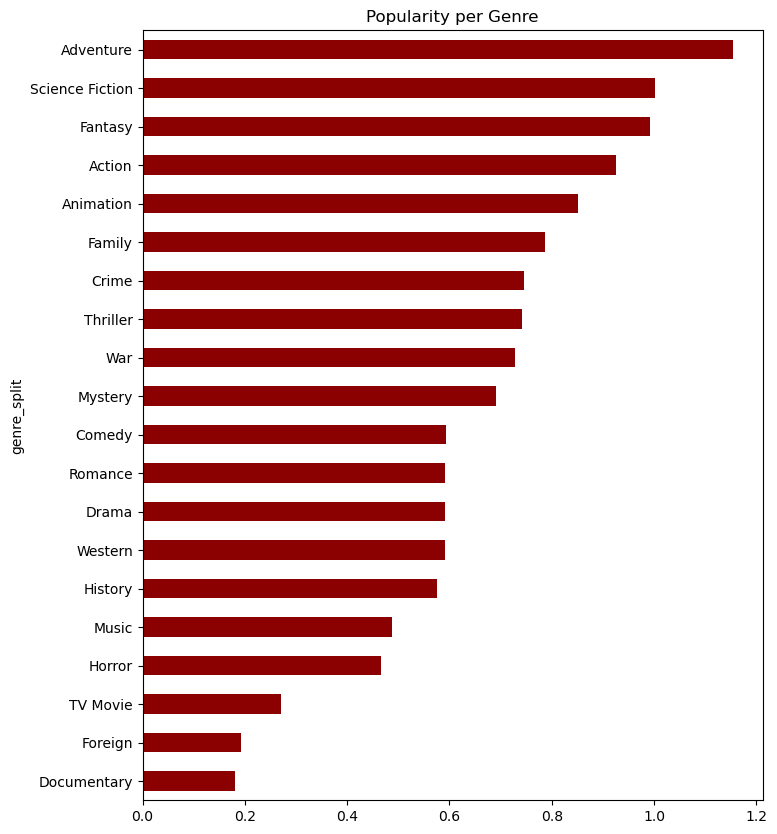

In [173]:
genre_avg['popularity'].plot.barh(title = 'Popularity per Genre', color = 'Darkred', figsize = (8,10))

In [174]:
#WHich genre has the highest number of movies with a voting avg>= 8??

In [175]:
vote_zero = movies_genre[movies_genre['vote_average'] >=8]
vote_fifty = movies_genre[(movies_genre['vote_count'] >= 50) &(movies_genre['vote_average'] >=8)]

In [176]:
genre_vote = pd.DataFrame(vote_fifty.groupby('genre_split').vote_average.nunique()).sort_values('vote_average', ascending = True)
genre_vote

,vote_average
genre_split,
Fantasy,1
Science Fiction,1
Animation,1
Mystery,1
Horror,1
Family,1
Romance,2
Music,2
History,2


<Axes: title={'center': 'Vote Average per Genre'}, ylabel='genre_split'>

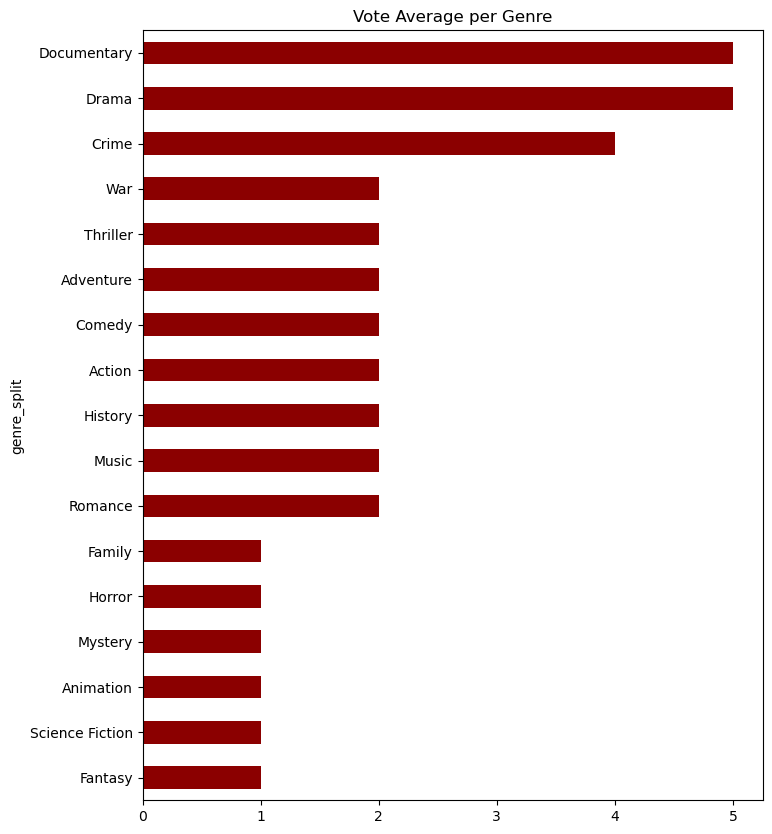

In [177]:
genre_vote['vote_average'].plot.barh(title = 'Vote Average per Genre', color = 'Darkred', figsize = (8,10))

In [178]:
## Now we have some hypothesis questions, in order to reply these I would need the table without genre split.

In [179]:
movies.drop_duplicates(inplace = True)
movies['profit'] = movies['revenue'] - movies['budget']
movies_genre = movies[['popularity', 'budget', 'revenue', 'original_title','runtime', 'genres', 'release_date', 'vote_count', 'vote_average', 'profit']]

In [180]:
## 1. The best movies according to vote avg. return high profit and revenue.

In [181]:
movies_fifty = movies_genre[movies_genre['vote_count']>= 50]

In [182]:
movies_fifty.corr(method = 'spearman', numeric_only = True)

,popularity,budget,revenue,runtime,vote_count,vote_average,profit
popularity,1.000000,0.485149,0.588739,0.230518,0.768966,0.188670,0.498117
budget,0.485149,1.000000,0.714828,0.360230,0.554586,-0.044440,0.334390
revenue,0.588739,0.714828,1.000000,0.341707,0.682656,0.111731,0.842221
runtime,0.230518,0.360230,0.341707,1.000000,0.263460,0.285514,0.212060
vote_count,0.768966,0.554586,0.682656,0.263460,1.000000,0.284470,0.583602
vote_average,0.188670,-0.044440,0.111731,0.285514,0.284470,1.000000,0.198308
profit,0.498117,0.334390,0.842221,0.212060,0.583602,0.198308,1.000000


In [183]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='vote_average', ylabel='profit'>

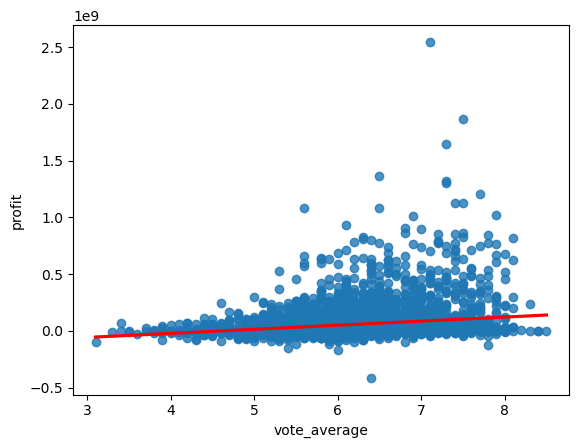

In [184]:
sns.regplot(x = 'vote_average', y = 'profit', data = movies_fifty , line_kws = {'color':'red'})

<Axes: xlabel='vote_average', ylabel='revenue'>

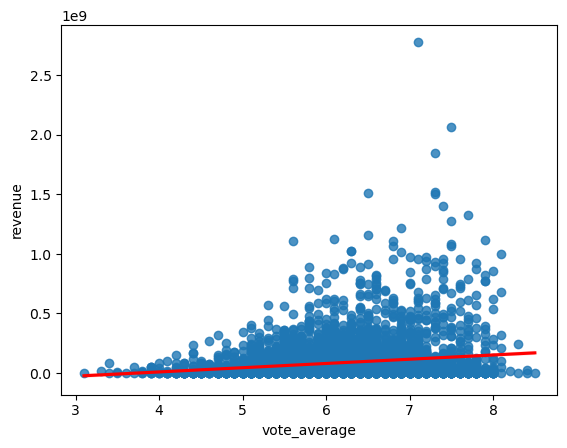

In [185]:
sns.regplot(x = 'vote_average', y = 'revenue', data = movies_fifty , line_kws = {'color':'red'})

In [186]:
## The best movies according to popularity return high profit and revenue.

<Axes: xlabel='popularity', ylabel='profit'>

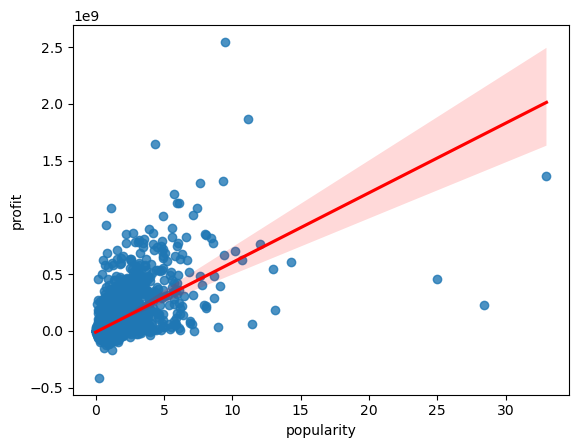

In [187]:
sns.regplot(x = 'popularity', y = 'profit', data = movies_fifty , line_kws = {'color':'red'})

<Axes: xlabel='popularity', ylabel='revenue'>

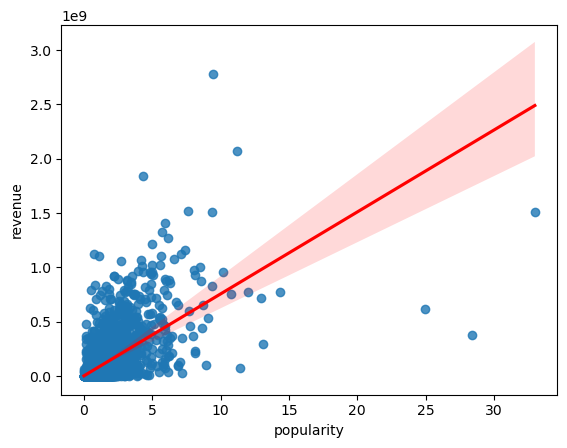

In [188]:
sns.regplot(x = 'popularity', y = 'revenue', data = movies_fifty , line_kws = {'color':'red'})

In [189]:
# highly budgeted movie return high profit.

<Axes: xlabel='budget', ylabel='profit'>

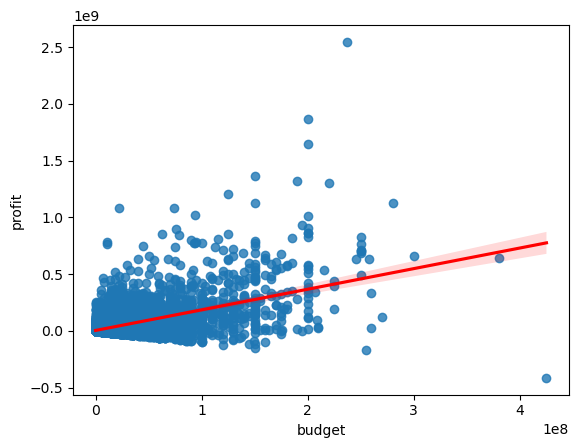

In [190]:
sns.regplot(x = 'budget', y = 'profit', data = movies_fifty , line_kws = {'color':'red'})

In [191]:
## Highly budgeted movies have hgih popularity.


<Axes: xlabel='budget', ylabel='popularity'>

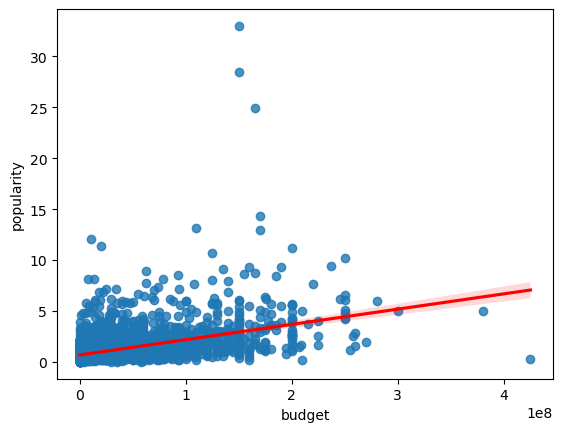

In [192]:
sns.regplot(x = 'budget', y = 'popularity', data = movies_fifty , line_kws = {'color':'red'})

In [ ]:
##  Bonus question: Profit per gener timeline

In [200]:
movies_genre.head()

,popularity,budget,revenue,original_title,runtime,release_year,vote_count,vote_average,profit,genre_split
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Action
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Adventure
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Science Fiction
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Thriller
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,2015,6185,7.100000,228436354,Action


In [204]:
time_genre = pd.DataFrame(movies_genre.groupby(['release_year', 'genre_split'])['profit'].mean())

In [212]:
pivot_genre = pd.pivot_table(time_genre , values = 'profit', index = ['genre_split'], columns = ['release_year'])

Text(0.5, 1.0, 'Genre Profit by Year')

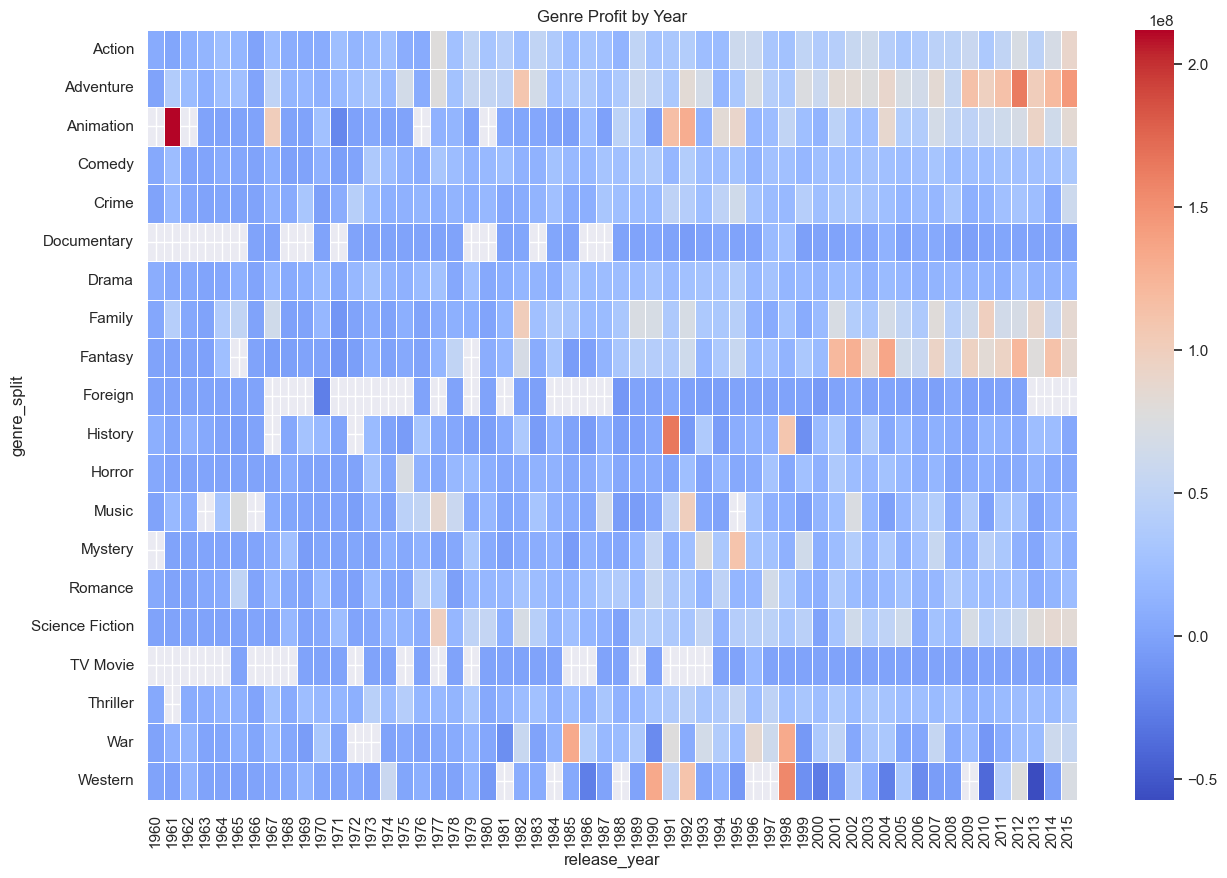

In [221]:
sns.set(rc = {'figure.figsize': (15,10)})
sns.heatmap(pivot_genre , cmap = 'coolwarm', linewidth = 0.5)
plt.title('Genre Profit by Year')